# AIC Degree Selection for Legendre Fits

This notebook visualises the **AIC model-selection** process used by the
pipeline: for each Legendre order $L = 0 \ldots L_\text{max}$, we fit
the angular distribution with ridge regularisation ($\lambda = 10^{-4}$),
compute the AIC score, and derive Akaike weights.  The plots make it
clear why a particular degree is chosen.

In [1]:
import sys
from pathlib import Path

# Add kika root to path
_kika_path = Path("/home/MONLEON-JUAN/kika")
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legvander, legval

from kika.exfor import read_all_exfor
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    build_union_energy_grid,
    compute_energy_bins_with_tof_resolution,
    filter_exfor_with_energy_bin,
)
from scripts.resample_AD import _weighted_ridge_fit, _criterion_score

## 1. Configuration

Same parameters as the production pipeline.

In [2]:
# --- Paths ---
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',
]

# --- Target ---
TARGET_ZAIDS = [26056, 26000]
MT_NUMBER = 2
ENERGY_MIN_MEV = 0.847
ENERGY_MAX_MEV = 4.0

# --- Masses (for LAB -> CM) ---
M_PROJ_U = 1.008665   # neutron
M_TARG_U = 55.93494   # Fe-56

# --- Fitting ---
MAX_LEGENDRE_DEGREE = 6
SELECT_DEGREE = "aic"
RIDGE_LAMBDA = 1e-4
RIDGE_POWER = 4
DF_METHOD = "hat"

# --- Data handling ---
EXCLUDE_EXPERIMENTS = ["32246002", "400750022"]
MIN_RELATIVE_UNCERTAINTY = 1e-4
UNCERTAINTY_FLOOR_STRATEGY = 'bin_median'
NORMALIZE_BY_N_POINTS = True
NORMALIZATION_SIGMA = 0.05
MAX_EXP_WEIGHT_FRAC_BIN = 0.80

# --- TOF resolution ---
DELTA_T_NS = 5.0
FLIGHT_PATH_M = 27.037

# --- Union grid ---
UNION_GRID_SUBENTRIES = [
    ("10571002", 0.847, 2.5),
    ("23365005", 2.5, 4),
]

## 2. Load EXFOR data and build energy grid

In [3]:
# Load EXFOR data
exfor_dict, _ = read_all_exfor(
    source="database",
    db_path=EXFOR_DB_PATH,
    target_zaid=TARGET_ZAIDS,
    projectile="N",
    mt=MT_NUMBER,
    energy_range=(ENERGY_MIN_MEV, ENERGY_MAX_MEV),
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
    group_by_energy=False,
    return_load_status=True,
)

exfor_cache, sorted_energies = build_exfor_cache_from_objects(
    list(exfor_dict.values()),
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)

n_files = sum(len(v) for v in exfor_cache.values())
print(f"Loaded {n_files} experiments at {len(sorted_energies)} energies")

  [uncertainty_manifest] 10571002 (manifest): σ_sys capped at σ_total on 350/16008 rows; σ_stat floored at 1% of |y| on 190/16008 rows.
  [uncertainty_manifest] 10886002 (manifest): σ_sys capped at σ_total on 20/490 rows; σ_stat floored at 1% of |y| on 13/490 rows.
  [uncertainty_manifest] 11220013 (default→total): σ_sys capped at σ_total on 9/30 rows; σ_stat floored at 1% of |y| on 4/30 rows.
  [uncertainty_manifest] 11316003 (default→total): σ_sys capped at σ_total on 2/55 rows; σ_stat floored at 1% of |y| on 2/55 rows.
  [uncertainty_manifest] 11396011 (default→total): σ_sys capped at σ_total on 7/25 rows; σ_stat floored at 1% of |y| on 3/25 rows.
  [uncertainty_manifest] 14451003 (default→total): σ_sys capped at σ_total on 12/12 rows; σ_stat floored at 1% of |y| on 5/12 rows.
  [uncertainty_manifest] 23365004 (default→total): σ_sys capped at σ_total on 185/952 rows; σ_stat floored at 1% of |y| on 141/952 rows.
  [uncertainty_manifest] 23365005 (default→total): σ_sys capped at σ_tot

In [4]:
# Build union energy grid and compute energy bins
grid_energies_ev = build_union_energy_grid(
    exfor_cache=exfor_cache,
    subentries=UNION_GRID_SUBENTRIES,
    energy_min_mev=ENERGY_MIN_MEV,
    energy_max_mev=ENERGY_MAX_MEV,
)

energy_bins = compute_energy_bins_with_tof_resolution(
    energies_ev=grid_energies_ev,
    energy_min_mev=ENERGY_MIN_MEV,
    energy_max_mev=ENERGY_MAX_MEV,
    delta_t_ns=DELTA_T_NS,
    flight_path_m=FLIGHT_PATH_M,
)

print(f"{len(energy_bins)} energy bins")
print(f"Energy range: [{energy_bins[0].energy_mev:.4f}, {energy_bins[-1].energy_mev:.4f}] MeV")

1738 energy bins
Energy range: [0.8470, 4.0000] MeV


## 3. Select energy and analyse

**Change `TARGET_ENERGY_MEV` below and re-run from here** — no need to
reload the EXFOR database (cells 1–2 above).

In [5]:
# ── Change this and re-run from here ──
TARGET_ENERGY_MEV = 1.2

In [6]:
# Find the energy bin closest to TARGET_ENERGY_MEV
bin_energies = np.array([b.energy_mev for b in energy_bins])
bin_idx = int(np.argmin(np.abs(bin_energies - TARGET_ENERGY_MEV)))
bin_info = energy_bins[bin_idx]

print(f"Requested energy: {TARGET_ENERGY_MEV:.4f} MeV")
print(f"Matched bin {bin_idx}: E = {bin_info.energy_mev:.4f} MeV")
print(f"  Bin bounds: [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV")

exfor_df, experiments_info, kernel_weights, diagnostics, floor_stats = filter_exfor_with_energy_bin(
    exfor_cache=exfor_cache,
    sorted_energies=sorted_energies,
    bin_lower_mev=bin_info.bin_lower_mev,
    bin_upper_mev=bin_info.bin_upper_mev,
    target_energy_mev=bin_info.energy_mev,
    m_proj_u=M_PROJ_U,
    m_targ_u=M_TARG_U,
    dedupe_per_experiment=True,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
    min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
    unc_floor_strategy=UNCERTAINTY_FLOOR_STRATEGY,
    normalize_by_n_points=NORMALIZE_BY_N_POINTS,
    sigma_norm=NORMALIZATION_SIGMA,
    max_experiment_weight_fraction=MAX_EXP_WEIGHT_FRAC_BIN,
)

print(f"  {len(exfor_df)} data points from {len(experiments_info)} experiments")
for exp in experiments_info:
    print(f"    {exp.get('entry','')}/{exp.get('subentry','')} — {exp.get('author','')} ({exp.get('year','')})")

Requested energy: 1.2000 MeV
Matched bin 353: E = 1.2000 MeV
  Bin bounds: [1.1995, 1.2005] MeV
  21 data points from 3 experiments
    20743/002 — Cierjacks (1978)
    10571/002 — Kinney (1976)
    20197/006 — Malmskog (1972)


## 4. Fit all Legendre orders and compute AICc weights

In [7]:
mu = exfor_df['mu'].to_numpy()
y = exfor_df['value'].to_numpy()
sigma = exfor_df['unc'].to_numpy()
n_pts = len(y)

# Sys-aware fit weights (production SIGMA_SYS_AWARE_FIT=True): use
# sigma_total = sqrt(sigma_stat^2 + sigma_sys^2) with per-point sigma_sys
# read from the manifest column. Matches the nominal pipeline fit.
if 'sigma_sys_relative' in exfor_df.columns:
    _ssys = exfor_df['sigma_sys_relative'].to_numpy(float) * np.abs(y)
    _ssys = np.where(np.isfinite(_ssys) & (_ssys > 0), _ssys, 0.0)
    sigma_fit = np.sqrt(sigma ** 2 + _ssys ** 2)
else:
    sigma_fit = sigma

# Cap max degree exactly as the pipeline does (resample_AD.py:1286-1289)
n_unique_mu = len(np.unique(np.round(mu, decimals=6)))
max_feasible = min(MAX_LEGENDRE_DEGREE, n_unique_mu - 1)
max_feasible = max(max_feasible, 0)

# Dense grid for plotting the fits
mu_plot = np.linspace(-1, 1, 301)
theta_plot = np.degrees(np.arccos(mu_plot))

# Fit every order from 0 to max_feasible
results = {}
for deg in range(max_feasible + 1):
    coeffs, chi2, dof, eff_p = _weighted_ridge_fit(
        mu=mu, y=y, sigma=sigma_fit,
        degree=deg,
        ridge_lambda=RIDGE_LAMBDA,
        ridge_power=RIDGE_POWER,
        df_method=DF_METHOD,
        external_weights=kernel_weights,
    )
    chi2_red = chi2 / max(dof, 1e-12)
    aic = _criterion_score(chi2, n_pts, eff_p, criterion=SELECT_DEGREE)
    y_fit = legval(mu_plot, coeffs)
    results[deg] = dict(
        coeffs=coeffs, chi2=chi2, dof=dof,
        eff_p=eff_p, chi2_red=chi2_red, aic=aic, y_fit=y_fit,
    )

# Compute delta-AIC and Akaike weights
aic_min = min(r['aic'] for r in results.values())
for r in results.values():
    r['delta_aic'] = r['aic'] - aic_min

raw_weights = {d: np.exp(-0.5 * r['delta_aic']) for d, r in results.items()}
w_sum = sum(raw_weights.values())
for d, r in results.items():
    r['weight'] = raw_weights[d] / w_sum

best_degree = max(results, key=lambda d: results[d]['weight'])
n_orders = max_feasible + 1

print(f"AIC-best degree: L = {best_degree}  (weight = {results[best_degree]['weight']:.1%})")
print(f"Max feasible degree: {max_feasible}  (n_unique_mu = {n_unique_mu})\n")

for deg in range(n_orders):
    r = results[deg]
    marker = " <<<" if deg == best_degree else ""
    print(
        f"  L={deg}  χ²/ν={r['chi2_red']:7.3f}  AIC={r['aic']:8.2f}  "
        f"ΔAIC={r['delta_aic']:7.2f}  w={r['weight']:6.1%}  "
        f"p_eff={r['eff_p']:.2f}{marker}"
    )

AIC-best degree: L = 2  (weight = 26.6%)
Max feasible degree: 6  (n_unique_mu = 21)

  L=0  χ²/ν=  8.112  AIC=  164.25  ΔAIC= 138.74  w=  0.0%  p_eff=1.00
  L=1  χ²/ν=  8.499  AIC=  165.48  ΔAIC= 139.97  w=  0.0%  p_eff=2.00
  L=2  χ²/ν=  1.084  AIC=   25.51  ΔAIC=   0.00  w= 26.6%  p_eff=3.00 <<<
  L=3  χ²/ν=  1.044  AIC=   25.75  ΔAIC=   0.24  w= 23.6%  p_eff=4.00
  L=4  χ²/ν=  0.979  AIC=   25.67  ΔAIC=   0.16  w= 24.6%  p_eff=5.00
  L=5  χ²/ν=  0.950  AIC=   26.26  ΔAIC=   0.75  w= 18.3%  p_eff=6.00
  L=6  χ²/ν=  1.016  AIC=   28.23  ΔAIC=   2.72  w=  6.8%  p_eff=7.00


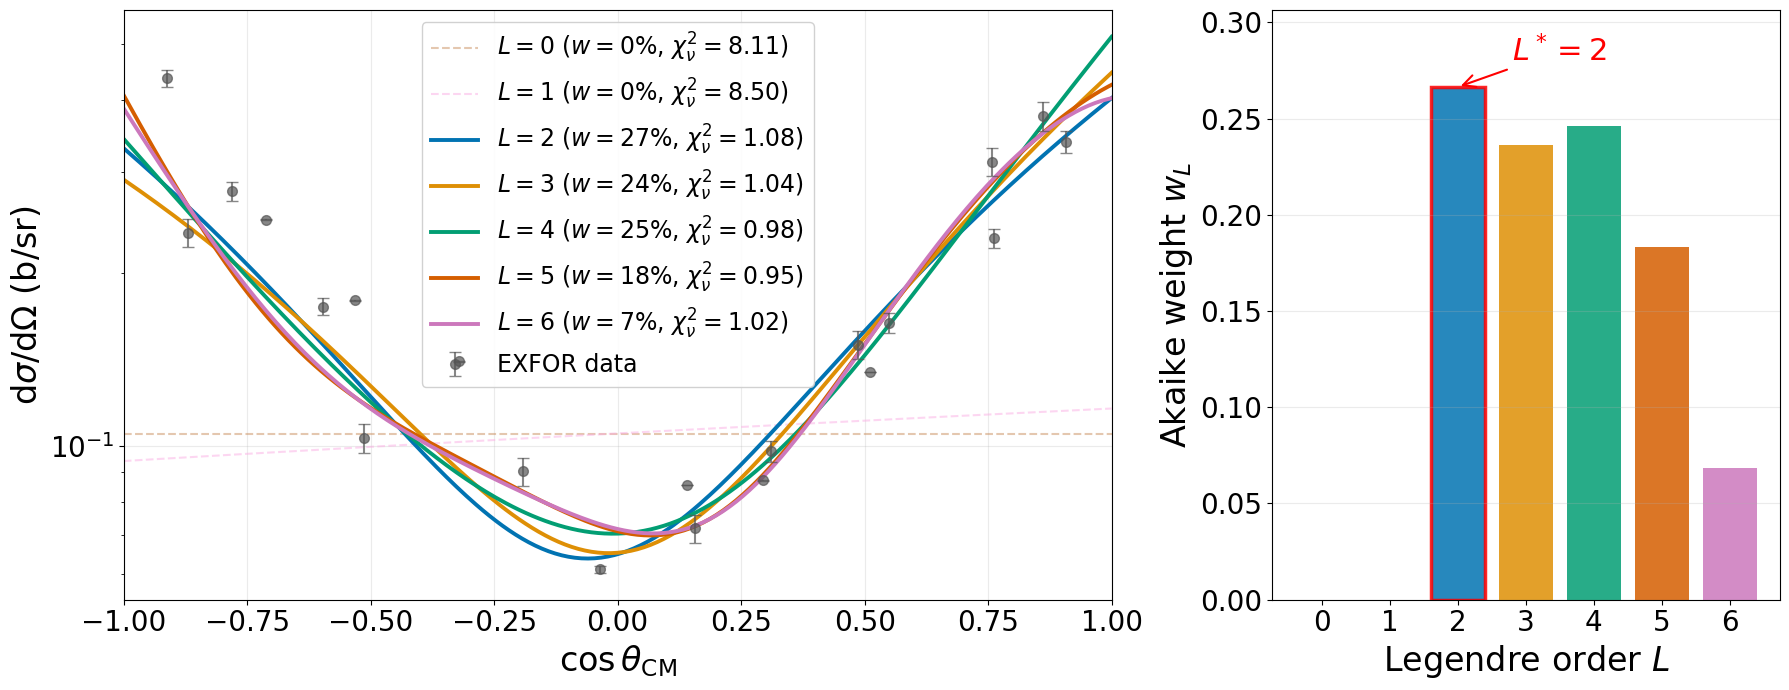

In [8]:
# Kika color-blind friendly palette (kika/plotting/styles.py)
COLORS = [
    '#0173B2',  # Blue
    '#DE8F05',  # Orange
    '#029E73',  # Green
    '#D55E00',  # Red/Dark Orange
    '#CC78BC',  # Magenta/Pink
    '#CA9161',  # Brown
    '#FBAFE4',  # Light Pink
    '#949494',  # Gray
    '#ECE133',  # Yellow
    '#56B4E9',  # Light Blue
]

WEIGHT_THRESHOLD = 0.005  # below this → dashed

# Assign colors: first palette color to first non-zero-weight order,
# then cycle through palette, wrapping around so zero-weight orders
# get the last colors.
nonzero_order = [d for d in range(n_orders) if results[d]['weight'] > WEIGHT_THRESHOLD]
zero_order = [d for d in range(n_orders) if results[d]['weight'] <= WEIGHT_THRESHOLD]
color_sequence = nonzero_order + zero_order
color_map = {}
for i, d in enumerate(color_sequence):
    color_map[d] = COLORS[i % len(COLORS)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [3.5, 1.8]})

# --- Left panel: angular distribution fits ---
ax = axes[0]

ax.errorbar(
    mu, y, yerr=sigma, fmt='o', color='#555555',
    ms=7, capsize=4, alpha=0.7, zorder=10, label='EXFOR data',
)

for deg in range(n_orders):
    r = results[deg]
    w = r['weight']
    ls = '-' if w > WEIGHT_THRESHOLD else '--'
    lw = 2.8 if w > WEIGHT_THRESHOLD else 1.5
    alpha = 1.0 if w > WEIGHT_THRESHOLD else 0.5
    w_pct = w * 100
    label = f"$L = {deg}$ ($w = {w_pct:.0f}\\%$, $\\chi^2_\\nu = {r['chi2_red']:.2f}$)"
    ax.plot(
        mu_plot, r['y_fit'], color=color_map[deg],
        lw=lw, ls=ls, alpha=alpha, label=label, zorder=2,
    )

ax.set_xlabel(r'$\cos\theta_{\mathrm{CM}}$', fontsize=24)
ax.set_ylabel(r'd$\sigma$/d$\Omega$ (b/sr)', fontsize=24)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=17, loc='best', framealpha=0.9)
ax.set_xlim(-1, 1)
ax.set_yscale('log')
ax.grid(True, alpha=0.25)

# --- Right panel: AIC weight bar chart ---
ax2 = axes[1]
degrees = list(range(n_orders))
weights = [results[d]['weight'] for d in degrees]
bar_colors = [color_map[d] for d in degrees]
edge_colors = ['red' if d == best_degree else 'none' for d in degrees]
edge_widths = [2.5 if d == best_degree else 0 for d in degrees]

ax2.bar(
    degrees, weights, color=bar_colors, edgecolor=edge_colors,
    linewidth=edge_widths, alpha=0.85,
)

ax2.set_xlabel('Legendre order $L$', fontsize=24)
ax2.set_ylabel('Akaike weight $w_L$', fontsize=24)
ax2.tick_params(axis='both', labelsize=20)
ax2.set_xticks(degrees)
ax2.set_ylim(0, max(weights) * 1.15)
ax2.grid(True, alpha=0.25, axis='y')

ax2.annotate(
    f'$L^* = {best_degree}$',
    xy=(best_degree, results[best_degree]['weight']),
    xytext=(best_degree + 0.8, results[best_degree]['weight'] * 1.05),
    fontsize=22, fontweight='bold', color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
)

fig.tight_layout()
plt.savefig('aic_degree_selection.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 5. Residuals comparison

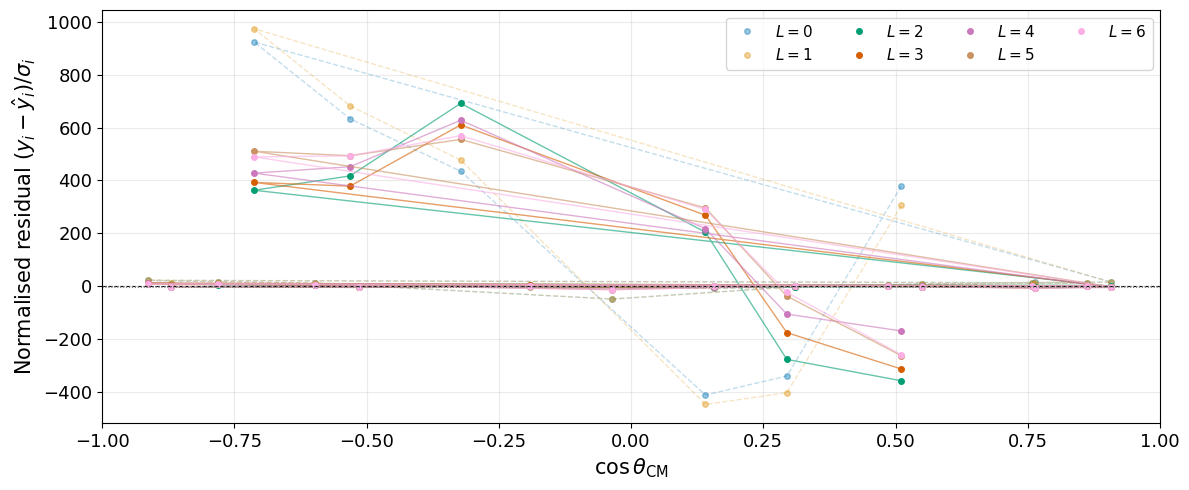

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

for deg in range(n_orders):
    r = results[deg]
    y_pred = legval(mu, r['coeffs'])
    residuals = (y - y_pred) / sigma
    w = r['weight']
    ls = '-' if w > WEIGHT_THRESHOLD else '--'
    alpha = 1.0 if w > WEIGHT_THRESHOLD else 0.4
    ax.plot(
        mu, residuals, 'o', color=COLORS[deg % len(COLORS)],
        ms=4, alpha=alpha, label=f'$L={deg}$',
    )
    ax.plot(
        mu, residuals, color=COLORS[deg % len(COLORS)],
        lw=1.0, ls=ls, alpha=alpha * 0.6,
    )

ax.axhline(0, color='k', ls='--', lw=0.8)
ax.axhline(2, color='grey', ls=':', lw=0.8)
ax.axhline(-2, color='grey', ls=':', lw=0.8)
ax.set_xlabel(r'$\cos\theta_{\mathrm{CM}}$', fontsize=15)
ax.set_ylabel(r'Normalised residual $(y_i - \hat{y}_i)/\sigma_i$', fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=11, ncol=4)
ax.set_xlim(-1, 1)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Summary table

In [10]:
rows = []
for deg in range(n_orders):
    r = results[deg]
    row = {
        'L': deg,
        'chi2': r['chi2'],
        'chi2_red': r['chi2_red'],
        'AIC': r['aic'],
        'delta_AIC': r['delta_aic'],
        'weight': r['weight'],
    }
    for l_idx in range(deg + 1):
        row[f'c{l_idx}'] = r['coeffs'][l_idx]
    rows.append(row)

summary = pd.DataFrame(rows)
summary.style.format({
    'chi2': '{:.2f}', 'chi2_red': '{:.3f}', 'AIC': '{:.2f}',
    'delta_AIC': '{:.2f}', 'weight': '{:.1%}',
    **{f'c{l}': '{:.5f}' for l in range(MAX_LEGENDRE_DEGREE + 1)},
}).highlight_min(subset=['AIC'], color='lightgreen')

,L,chi2,chi2_red,AIC,delta_AIC,weight,c0,c1,c2,c3,c4,c5,c6
0,0,162.25,8.112,164.25,138.74,0.0%,0.10506,nan,nan,nan,nan,nan,nan
1,1,161.48,8.499,165.48,139.97,0.0%,0.10518,0.01102,nan,nan,nan,nan,nan
2,2,19.51,1.084,25.51,0.00,26.6%,0.16527,0.03671,0.20087,nan,nan,nan,nan
3,3,17.75,1.044,25.75,0.24,23.6%,0.16620,0.05099,0.20199,0.02668,nan,nan,nan
4,4,15.67,0.979,25.67,0.16,24.6%,0.16955,0.05344,0.22428,0.03303,0.03466,nan,nan
5,5,14.26,0.950,26.26,0.75,18.3%,0.16905,0.04389,0.21788,0.00349,0.02916,-0.03858,nan
6,6,14.23,1.016,28.23,2.72,6.8%,0.16828,0.04340,0.21369,0.00305,0.02062,-0.03825,-0.00812
